# FiLM Feature Importance (RBP + HVG)

读取训练好的 FiLM 模型，解析 `expression_film` 的权重，对输入特征（RBP + HVG）做重要性排序，并绘制 Top 20 调控因子。

> 本笔记本只提供代码框架，需在有模型和特征矩阵的环境中运行。

In [4]:
import json
from pathlib import Path
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 配置
checkpoint_path = Path('/home1/xyf/data/openspliceai_tissue_data/train_model/all_tissue_400_uf1/SpliceAI_all_tissue_400_uf1_400_0_rs42/0/models/model_best.pt')
feature_matrix = Path('/home1/xyf/project/github/OpenSpliceAI/data/tissue_expression_features_scaled.csv')  # 列名为特征名
output_plot = Path('film_feature_top20.png')
top_k = 20


In [5]:
# 读取特征名
df_feat = pd.read_csv(feature_matrix, index_col=0)
feature_names = df_feat.columns.tolist()
in_dim = len(feature_names)

# 加载 checkpoint
state = torch.load(checkpoint_path, map_location='cpu')

# 提取 FiLM 权重
w_in = state['expression_film.affine.0.weight']      # [hidden, in_dim]
b_in = state['expression_film.affine.0.bias']        # [hidden]
w_out = state['expression_film.affine.4.weight']     # [2*channels, hidden]
b_out = state['expression_film.affine.4.bias']       # [2*channels]

hidden, in_dim_ckpt = w_in.shape
out_dim, hidden_ckpt = w_out.shape
channels = out_dim // 2
print(f'in_dim: {in_dim_ckpt}, hidden: {hidden_ckpt}, channels: {channels}')
assert in_dim_ckpt == in_dim, '特征维度与矩阵列数不一致！'


in_dim: 753, hidden: 128, channels: 32


In [6]:
# 简单重要性度量：
# 对 gamma 和 beta 的通道，分别计算 |w_out| @ |w_in| （相当于线性组合绝对值），再对通道取平均。
w_in_abs = w_in.abs().numpy()            # [hidden, in_dim]
w_out_abs = w_out.abs().numpy()          # [2*channels, hidden]

gamma_out = w_out_abs[:channels]         # [channels, hidden]
beta_out = w_out_abs[channels:]         # [channels, hidden]

gamma_importance = gamma_out @ w_in_abs  # [channels, in_dim]
beta_importance = beta_out @ w_in_abs    # [channels, in_dim]

combined = (gamma_importance + beta_importance) / 2.0  # [channels, in_dim]
feature_importance = combined.mean(axis=0)             # [in_dim]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
importance_df.head(top_k)


,feature,importance
210,TNNT2,0.009760
485,SRRM4,0.009519
450,SNCG,0.009503
441,MYL7,0.009451
304,EYA1,0.009450
367,EYA2,0.009428
190,ZIC1,0.009423
9,RAB25,0.009384
705,TCF21,0.009335
580,XPO1,0.009312


In [11]:
list(importance_df.head(top_k)['feature'])

['TNNT2',
 'SRRM4',
 'SNCG',
 'MYL7',
 'EYA1',
 'EYA2',
 'ZIC1',
 'RAB25',
 'TCF21',
 'XPO1',
 'SDK1',
 'IGDCC3',
 'ESAM',
 'METTL3',
 'YBX3',
 'TPT1',
 'STMN2',
 'NFIB',
 'PRPF6',
 'HNRNPCL1']

In [12]:
rbp_file_path = '/home1/xyf/project/github/OpenSpliceAI/data/all_RBP_gene_names.txt'
with open(rbp_file_path, 'r') as f:
    # 读取每一行，去除首尾空格
    rbp_genes = set([line.strip() for line in f if line.strip()])

In [16]:
for i in list(importance_df.head(top_k)['feature']):
    print(i in rbp_genes)

False
False
False
False
False
False
False
False
False
True
False
False
False
True
True
False
False
False
True
True


Saved plot to film_feature_top20.png


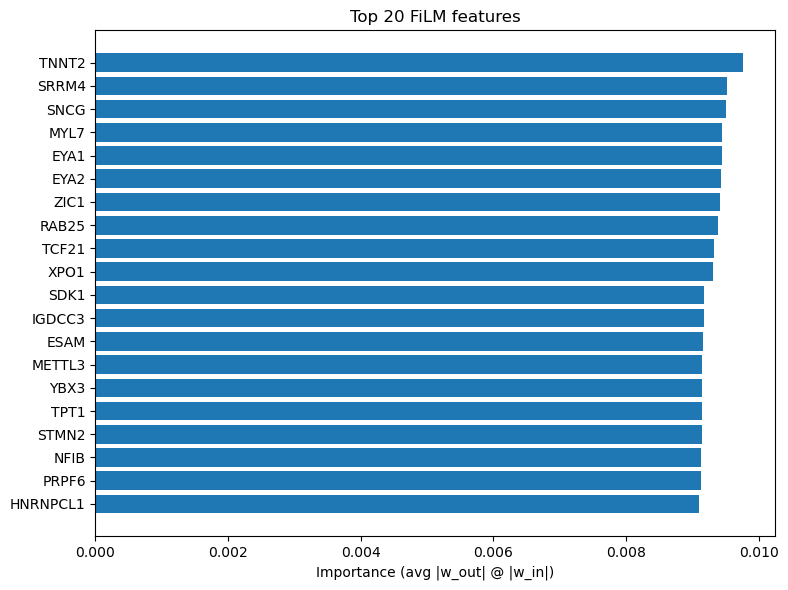

In [7]:
# 绘制 Top K
top_df = importance_df.head(top_k)
plt.figure(figsize=(8, 6))
plt.barh(top_df['feature'][::-1], top_df['importance'][::-1])
plt.xlabel('Importance (avg |w_out| @ |w_in|)')
plt.title(f'Top {top_k} FiLM features')
plt.tight_layout()
plt.savefig(output_plot, dpi=200)
print(f'Saved plot to {output_plot}')
